# ML Lab 5: Linear Regression — Predicting House Prices

## Student Information
- Name: Abdul Rafiu
- Student ID: 023-24-0265
- Section: H
- GitHub: https://github.com/AbdulRafiu7/ML-lab-5
- Kaggle: abrafay7
- Dataset: House Prices - Advanced Regression Techniques
- Dataset Source: Kaggle

In [ ]:
#Part 1 — Dataset, Problem & Feature/Target Identification
#task1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#task3

This is regression problem because we predict the saleprice which is the target variable. unlike classification problem that predict the categories. and this problem will be evaluted by regression metrics like MSE, MAE, RMSE, etc..

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

train_file= '/content/drive/MyDrive/Colab Notebooks/ML LAB 5/train.csv'
test_file = '/content/drive/MyDrive/Colab Notebooks/ML LAB 5/test.csv'
df = pd.read_csv(train_file)
df1 = pd.read_csv(test_file)
display('shape of train.csv', df.shape)
print('Shape of test.csv', df1.shape)

'shape of train.csv'

(1460, 81)

Shape of test.csv (1459, 80)


In [ ]:
#Part 2 — Data Preparation & Train/Test Split
#task4
y=df["SalePrice"]
X=df.drop("SalePrice", axis=1)

categories_cols=X.select_dtypes(include="object").columns
print("Categorical columns:", list(categories_cols))

X=pd.get_dummies(X,categories_cols,drop_first=True)
print(X.head())




Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   

for categories columns with multiple categories, we use one hot encoding to convert the categories into numerical datatypes because there is no any natural order between categories.

In [ ]:
#task5
X = X.fillna(X.median())
print(X.isna().sum())
X.isnull().sum().sum(), X.shape

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
OverallQual              0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 245, dtype: int64


(np.int64(0), (1460, 245))

In [ ]:
#task6
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1168, 245), (292, 245))

In [ ]:
#Part 3 — Linear Regression & Predictions
#task7
model = LinearRegression()
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
test_pred[:10]

array([159859.60675125, 348018.36498687,  83487.74607698, 175104.91846634,
       326629.29928128,  68399.06269555, 233151.48141241, 147031.02552995,
        63846.85472529, 151457.63439568])

In [ ]:
#task8
comparison=pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted":test_pred[:10]
})

comparison

,Actual,Predicted
892,154500,159859.606751
1105,325000,348018.364987
413,115000,83487.746077
522,159000,175104.918466
1036,315500,326629.299281
614,75500,68399.062696
218,311500,233151.481412
1160,146000,147031.025530
649,84500,63846.854725
887,135500,151457.634396


In [ ]:
#Part 4 — Coefficients & Intercept
#task9
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_table.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
).head(10)

,Feature,Coefficient
113,RoofMatl_Metal,658820.608606
117,RoofMatl_WdShngl,624444.671903
115,RoofMatl_Tar&Grv,617544.825101
114,RoofMatl_Roll,616281.926404
111,RoofMatl_CompShg,614721.600066
116,RoofMatl_WdShake,611622.416022
91,Condition2_PosN,-233052.694195
216,GarageQual_Po,-178385.734870
214,GarageQual_Fa,-164369.125775
215,GarageQual_Gd,-160276.098482


#task10

A positive coefficient means that increasing the feature is associated with an increase in predicted price,
while a negative coefficient means the opposite while keeping other features constant.

The intercept represents the predicted price when all features are zero.
For house prices this usually has no meaningful real-world interpretation because a house cannot have all features equal to zero.


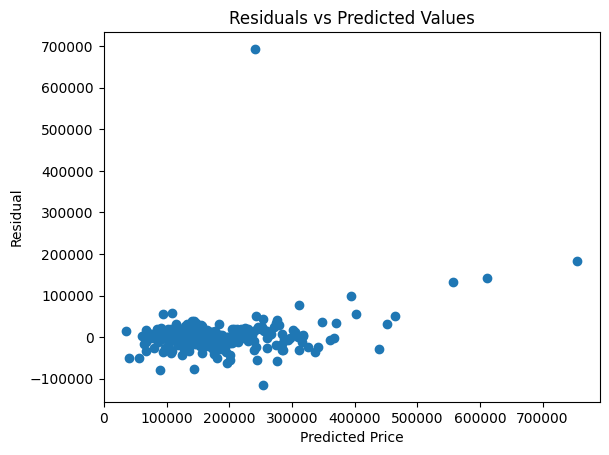

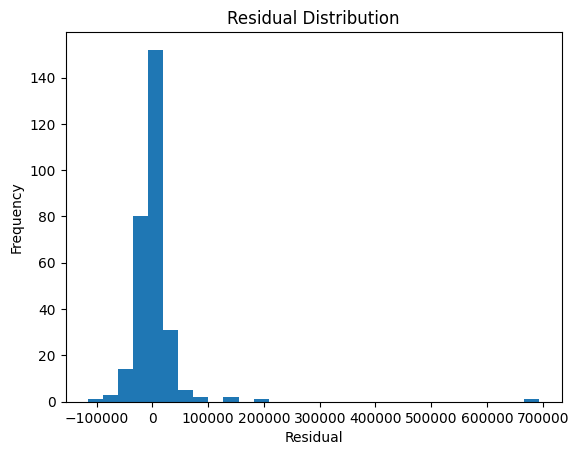

In [ ]:
#Part 5 — Residuals & Regression Metrics
#task11
residual=y_test-test_pred
plt.scatter(y_test,residual)
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.show()

plt.hist(residual, bins=30)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#task12
metrics = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R2'],
    'Value':[
        mean_absolute_error(y_test,test_pred),
        mean_squared_error(y_test,test_pred),
        np.sqrt(mean_squared_error(y_test,test_pred)),
        r2_score(y_test,test_pred)
    ]
})

metrics

,Metric,Value
0,MAE,2.049851e+04
1,MSE,2.429424e+09
2,RMSE,4.928919e+04
3,R2,6.832698e-01


#task13

Metric meanings:
- MAE: Average absolute prediction error.
- MSE: Average squared error; penalizes large errors more.
- RMSE: Error in the same unit as house price.
- R²: Percentage of variance explained by the model.

RMSE is usually easier to explain to non-technical stakeholders because it represents typical prediction error in price units.


In [ ]:
#part6
#task14
train_pred = model.predict(X_train)

comparison_metrics = pd.DataFrame({
    'Dataset':['Training','Testing'],
    'MAE':[
        mean_absolute_error(y_train,train_pred),
        mean_absolute_error(y_test,test_pred)
    ],
    'RMSE':[
        np.sqrt(mean_squared_error(y_train,train_pred)),
        np.sqrt(mean_squared_error(y_test,test_pred))
    ],
    'R2':[
        r2_score(y_train,train_pred),
        r2_score(y_test,test_pred)
    ]
})

comparison_metrics


,Dataset,MAE,RMSE,R2
0,Training,12601.908240,19500.833828,0.936243
1,Testing,20498.507157,49289.186669,0.683270


#task15

The training and testing performance should be compared to determine how well
the model generalizes to unseen data. A large difference between training and
testing performance would suggest overfitting, meaning the model performs well
on the data it learned from but poorly on new data. If the training and testing
metrics are relatively close, the model has better generalization and there is
less evidence of severe overfitting. In this experiment, the actual size of the
gap should be judged from the values produced in the comparison table.

In [ ]:
#Part 7 — Final Model Analysis, Conclusion & Kaggle Submission
#task16
influential_features = coef_table.copy()

influential_features['Absolute_Coefficient'] = (
    influential_features['Coefficient'].abs()
)

influential_features = influential_features.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

influential_features.head(10)

,Feature,Coefficient,Absolute_Coefficient
113,RoofMatl_Metal,658820.608606,658820.608606
117,RoofMatl_WdShngl,624444.671903,624444.671903
115,RoofMatl_Tar&Grv,617544.825101,617544.825101
114,RoofMatl_Roll,616281.926404,616281.926404
111,RoofMatl_CompShg,614721.600066,614721.600066
116,RoofMatl_WdShake,611622.416022,611622.416022
91,Condition2_PosN,-233052.694195,233052.694195
216,GarageQual_Po,-178385.734870,178385.734870
214,GarageQual_Fa,-164369.125775,164369.125775
215,GarageQual_Gd,-160276.098482,160276.098482


The 2–3 most influential features are identified by examining the largest
absolute coefficient values. A positive coefficient indicates an association
with a higher predicted SalePrice, while a negative coefficient indicates an
association with a lower predicted SalePrice, holding the other variables
constant. However, coefficient magnitude alone does not necessarily mean that
a feature is more important because numerical features can have very different
scales. For example, a coefficient measured per square foot and a coefficient
measured per year cannot be directly compared without considering their units.

#task17

The Linear Regression model provides a useful baseline for predicting house prices using selected numerical and categorical features. Its performance can be evaluated using MAE, MSE, RMSE, and R², with the test-set results showing how well the model generalizes to unseen houses. RMSE is particularly useful for communicating performance to a non-technical stakeholder because it expresses prediction error in the same units as the house price. The feature with the strongest effect can be identified from the coefficient table by examining the largest absolute coefficient, while remembering that coefficient magnitudes depend on the scales of the features. Linear Regression has limitations for this dataset because house prices can have complex and non-linear relationships with features, and interactions between variables may not be captured well by a simple linear model. It can also be sensitive to outliers and correlated features. As a next step, I would try feature engineering, regularized models such as Ridge or Lasso, and tree-based models such as Random Forest or Gradient Boosting to compare their performance.


In [ ]:
X_kaggle_test = df1.copy()

X_kaggle_test = pd.get_dummies(
    X_kaggle_test,
    columns=categories_cols,
    drop_first=True
)

X_kaggle_test = X_kaggle_test.reindex(
    columns=X.columns,
    fill_value=0
)

X_kaggle_test = X_kaggle_test.fillna(X.median())

kaggle_predictions = model.predict(X_kaggle_test)

submission = pd.DataFrame({
    'Id': df1['Id'],
    'SalePrice': kaggle_predictions
})

submission.to_csv('submission.csv', index=False)

print(submission.shape)
print(submission.head())

(1459, 2)
     Id      SalePrice
0  1461 -498013.918091
1  1462 -455402.421865
2  1463 -426223.112372
3  1464 -422209.186364
4  1465 -404186.696369


### Kaggle Submission Result

Public Leaderboard Score: 11.94749
Public Leaderboard Rank: 3341

The model was submitted to Kaggle using the generated submission.csv file.